<a href="https://colab.research.google.com/github/sharmaaviraj/Deep-Learning-Assignment-Reports/blob/main/Assignment_1_Aviraj_Sharma_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment I — Deep Learning

**Name:** Aviraj Sharma  
**SAP ID:** 590016470  
**Batch:** 24  
**Course:** Deep Learning

# Task 1: Computation in a Neural Network — 10 Marks

## Question 1.1 — Initialize all weights and biases using a fixed random seed. (2 marks)

**Architecture:** 4 inputs → 5 ReLU neurons → 3 ReLU neurons → 1 Sigmoid neuron.

In [2]:
import numpy as np

np.random.seed(42)

X = np.array([
    [1.0, 2.0, 0.5, 1.5],
    [2.0, 1.0, 1.5, 0.5],
    [0.5, 1.5, 2.0, 1.0],
    [1.5, 0.5, 1.0, 2.0]
])

W1 = np.random.randn(4, 5) * 0.1
b1 = np.zeros((1, 5))

W2 = np.random.randn(5, 3) * 0.1
b2 = np.zeros((1, 3))

W3 = np.random.randn(3, 1) * 0.1
b3 = np.zeros((1, 1))

print("Weights and biases initialized with seed 42.")
print("X shape:", X.shape)

Weights and biases initialized with seed 42.
X shape: (4, 4)


## Question 1.2 — Implement ReLU and Sigmoid activation functions without using deep-learning libraries. (2 marks)

In [3]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

test = np.array([-2.0, 0.0, 2.0])

print("ReLU:", relu(test))
print("Sigmoid:", sigmoid(test))

ReLU: [0. 0. 2.]
Sigmoid: [0.11920292 0.5        0.88079708]


## Question 1.3 — Perform forward propagation using matrix multiplication and broadcasting. (3 marks)

In [4]:
Z1 = X @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2 = relu(Z2)

Z3 = A2 @ W3 + b3
A3 = sigmoid(Z3)

print("Final output probabilities:\n", A3)

Final output probabilities:
 [[0.50001839]
 [0.50004789]
 [0.50003449]
 [0.50004366]]


## Question 1.4 — Print the shape of every weight, bias, pre-activation and activation tensor. (1 mark)

In [5]:
tensors = {
    "W1": W1, "b1": b1, "Z1": Z1, "A1": A1,
    "W2": W2, "b2": b2, "Z2": Z2, "A2": A2,
    "W3": W3, "b3": b3, "Z3": Z3, "A3": A3
}

for name, value in tensors.items():
    print(f"{name}: {value.shape}")

W1: (4, 5)
b1: (1, 5)
Z1: (4, 5)
A1: (4, 5)
W2: (5, 3)
b2: (1, 3)
Z2: (4, 3)
A2: (4, 3)
W3: (3, 1)
b3: (1, 1)
Z3: (4, 1)
A3: (4, 1)


## Question 1.5 — Display the final prediction for every input sample and classify it using a threshold of 0.5. (2 marks)

In [6]:
classes = (A3 >= 0.5).astype(int)

for i, (prob, cls) in enumerate(zip(A3.ravel(), classes.ravel()), 1):
    print(f"Sample {i}: probability = {prob:.6f}, class = {cls}")

Sample 1: probability = 0.500018, class = 1
Sample 2: probability = 0.500048, class = 1
Sample 3: probability = 0.500034, class = 1
Sample 4: probability = 0.500044, class = 1


# Task 2: Matrix Magic and Tensor Operations — 10 Marks

## Question 2.1 — Perform element-wise addition, subtraction, multiplication and division using compatible matrices. (2 marks)

In [7]:
A = np.array([[2,1,3],
              [1,0,2],
              [4,1,1]], dtype=float)

B = np.array([[1,2],
              [0,1],
              [3,2]], dtype=float)

C = np.array([[1,2,1],
              [2,1,4],
              [1,2,2]], dtype=float)

print("A + C =\n", A + C)

print("\nA - C =\n", A - C)

print("\nA * C =\n", A * C)

print("\nA / C =\n", A / C)

A + C =
 [[3. 3. 4.]
 [3. 1. 6.]
 [5. 3. 3.]]

A - C =
 [[ 1. -1.  2.]
 [-1. -1. -2.]
 [ 3. -1. -1.]]

A * C =
 [[2. 2. 3.]
 [2. 0. 8.]
 [4. 2. 2.]]

A / C =
 [[2.  0.5 3. ]
 [0.5 0.  0.5]
 [4.  0.5 0.5]]


## Question 2.2 — Compute matrix product AB using np.matmul(), @, and np.einsum(). Verify all three are equal. (3 marks)

In [8]:
AB1 = np.matmul(A, B)
AB2 = A @ B
AB3 = np.einsum('ij,jk->ik', A, B)

print("np.matmul:\n", AB1)

print("\n@ operator:\n", AB2)

print("\nnp.einsum:\n", AB3)

print("\nAll equal:", np.allclose(AB1, AB2) and np.allclose(AB1, AB3))

np.matmul:
 [[11. 11.]
 [ 7.  6.]
 [ 7. 11.]]

@ operator:
 [[11. 11.]
 [ 7.  6.]
 [ 7. 11.]]

np.einsum:
 [[11. 11.]
 [ 7.  6.]
 [ 7. 11.]]

All equal: True


## Question 2.3 — Compute the transpose, determinant, inverse and rank of matrix A. (2 marks)

In [9]:
print("Transpose:\n", A.T)

print("\nDeterminant:", np.linalg.det(A))

print("\nInverse:\n", np.linalg.inv(A))

print("\nRank:", np.linalg.matrix_rank(A))

Transpose:
 [[2. 1. 4.]
 [1. 0. 1.]
 [3. 2. 1.]]

Determinant: 6.0

Inverse:
 [[-0.33333333  0.33333333  0.33333333]
 [ 1.16666667 -1.66666667 -0.16666667]
 [ 0.16666667  0.33333333 -0.16666667]]

Rank: 3


## Question 2.4 — Verify through code that (AB)ᵀ = BᵀAᵀ. (1 mark)

In [10]:
lhs = (A @ B).T
rhs = B.T @ A.T

print("(AB)^T:\n", lhs)

print("\nB^T A^T:\n", rhs)

print("\nVerified:", np.allclose(lhs, rhs))

(AB)^T:
 [[11.  7.  7.]
 [11.  6. 11.]]

B^T A^T:
 [[11.  7.  7.]
 [11.  6. 11.]]

Verified: True


## Question 2.5 — Create a 3D tensor of shape (2, 3, 4) and perform indexing, slicing, element-wise squaring and summation along each axis. (2 marks)

In [11]:
tensor = np.arange(24).reshape(2, 3, 4)

print("Tensor:\n", tensor)

print("\nIndex tensor[1,2,3]:", tensor[1,2,3])

print("\nSlice tensor[:,1,:]:\n", tensor[:,1,:])

print("\nSquared:\n", tensor**2)

print("\nSum axis 0:\n", tensor.sum(axis=0))

print("\nSum axis 1:\n", tensor.sum(axis=1))

print("\nSum axis 2:\n", tensor.sum(axis=2))

Tensor:
 [[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]

Index tensor[1,2,3]: 23

Slice tensor[:,1,:]:
 [[ 4  5  6  7]
 [16 17 18 19]]

Squared:
 [[[  0   1   4   9]
  [ 16  25  36  49]
  [ 64  81 100 121]]

 [[144 169 196 225]
  [256 289 324 361]
  [400 441 484 529]]]

Sum axis 0:
 [[12 14 16 18]
 [20 22 24 26]
 [28 30 32 34]]

Sum axis 1:
 [[12 15 18 21]
 [48 51 54 57]]

Sum axis 2:
 [[ 6 22 38]
 [54 70 86]]


# Task 3: Array Broadcasting and Morphing Tensor Shapes — 10 Marks

## Question 3.1 — Print the tensor's shape, number of dimensions, size and data type. (1 mark)

In [12]:
images = np.arange(48).reshape(3, 4, 4)

print("Shape:", images.shape)
print("Dimensions:", images.ndim)
print("Size:", images.size)
print("Data type:", images.dtype)

Shape: (3, 4, 4)
Dimensions: 3
Size: 48
Data type: int64


## Question 3.2 — Normalize every image independently to [0,1] using broadcasting and no loops. (3 marks)

In [13]:
mins = images.min(axis=(1,2), keepdims=True)
maxs = images.max(axis=(1,2), keepdims=True)

normalized = (images - mins) / (maxs - mins)

print(normalized)

print("\nPer-image minimums:", normalized.min(axis=(1,2)))
print("Per-image maximums:", normalized.max(axis=(1,2)))

[[[0.         0.06666667 0.13333333 0.2       ]
  [0.26666667 0.33333333 0.4        0.46666667]
  [0.53333333 0.6        0.66666667 0.73333333]
  [0.8        0.86666667 0.93333333 1.        ]]

 [[0.         0.06666667 0.13333333 0.2       ]
  [0.26666667 0.33333333 0.4        0.46666667]
  [0.53333333 0.6        0.66666667 0.73333333]
  [0.8        0.86666667 0.93333333 1.        ]]

 [[0.         0.06666667 0.13333333 0.2       ]
  [0.26666667 0.33333333 0.4        0.46666667]
  [0.53333333 0.6        0.66666667 0.73333333]
  [0.8        0.86666667 0.93333333 1.        ]]]

Per-image minimums: [0. 0. 0.]
Per-image maximums: [1. 1. 1.]


## Question 3.3 — Add the following row-wise bias to every image using broadcasting. (2 marks)

In [14]:
row_bias = np.array([0.1, 0.2, 0.3, 0.4])

biased_images = images + row_bias.reshape(1,4,1)

print("Broadcast bias shape:", row_bias.reshape(1,4,1).shape)
print("Biased images:\n", biased_images)

Broadcast bias shape: (1, 4, 1)
Biased images:
 [[[ 0.1  1.1  2.1  3.1]
  [ 4.2  5.2  6.2  7.2]
  [ 8.3  9.3 10.3 11.3]
  [12.4 13.4 14.4 15.4]]

 [[16.1 17.1 18.1 19.1]
  [20.2 21.2 22.2 23.2]
  [24.3 25.3 26.3 27.3]
  [28.4 29.4 30.4 31.4]]

 [[32.1 33.1 34.1 35.1]
  [36.2 37.2 38.2 39.2]
  [40.3 41.3 42.3 43.3]
  [44.4 45.4 46.4 47.4]]]


## Question 3.4 — Convert (3,4,4) → (3,16) → (48,) → (2,3,2,4) and print each shape. (2 marks)

In [15]:
s1 = images
s2 = s1.reshape(3,16)
s3 = s2.reshape(48,)
s4 = s3.reshape(2,3,2,4)

print(s1.shape)
print(s2.shape)
print(s3.shape)
print(s4.shape)

(3, 4, 4)
(3, 16)
(48,)
(2, 3, 2, 4)


## Question 3.5 — Transpose (batch,height,width) to (height,width,batch). Explain why reshaping and transposing are not equivalent. (2 marks)

In [16]:
transposed = images.transpose(1,2,0)
reshaped = images.reshape(4,4,3)

print("Original shape:", images.shape)
print("Transposed shape:", transposed.shape)
print("Same as reshape(4,4,3)?", np.array_equal(transposed, reshaped))

explanation = (
    "reshape() changes how the sequential elements are grouped into dimensions, "
    "while transpose() reorders the axes. Therefore, two arrays can have the "
    "same final shape but contain elements in different positions."
)

print("\nExplanation:", explanation)

Original shape: (3, 4, 4)
Transposed shape: (4, 4, 3)
Same as reshape(4,4,3)? False

Explanation: reshape() changes how the sequential elements are grouped into dimensions, while transpose() reorders the axes. Therefore, two arrays can have the same final shape but contain elements in different positions.


## Question 4.1 — Calculate the inner product using np.dot(), @, and element-wise multiplication followed by summation. Verify identical results. (2 marks)

In [17]:
x = np.array([2.0, 1.0, 3.0])
w_vec = np.array([0.5, -1.0, 2.0])

r1 = np.dot(x, w_vec)
r2 = x @ w_vec
r3 = np.sum(x * w_vec)

print("np.dot:", r1)
print("@:", r2)
print("Element-wise + sum:", r3)
print("Identical:", np.allclose([r1, r2], r3))

np.dot: 6.0
@: 6.0
Element-wise + sum: 6.0
Identical: True


## Question 4.2 — Generate 200 two-dimensional data points belonging to two classes using a fixed random seed. (2 marks)

In [18]:
import matplotlib.pyplot as plt

np.random.seed(42)

class0 = np.random.randn(100, 2) + np.array([-2.0, -2.0])
class1 = np.random.randn(100, 2) + np.array([2.0, 2.0])

X_binary = np.vstack([class0, class1])
y_binary = np.hstack([np.zeros(100), np.ones(100)])

print("X shape:", X_binary.shape)
print("y shape:", y_binary.shape)

X shape: (200, 2)
y shape: (200,)


## Question 4.3 — Implement a single-neuron binary classifier without a built-in neural-network layer. (2 marks)

In [19]:
def sigmoid_stable(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

weights = np.zeros(2)
bias = 0.0
lr = 0.1

for _ in range(1000):
    probs = sigmoid_stable(X_binary @ weights + bias)
    error = probs - y_binary

    weights -= lr * (X_binary.T @ error) / len(y_binary)
    bias -= lr * np.mean(error)

probabilities = sigmoid_stable(X_binary @ weights + bias)
predictions = (probabilities >= 0.5).astype(int)

print("Weights:", weights)
print("Bias:", bias)
print("Accuracy:", np.mean(predictions == y_binary))

Weights: [1.7956393  2.06074439]
Bias: 0.06217020400426593
Accuracy: 0.995


## Question 4.4 — Plot the two classes with decision boundary, sigmoid curve, and histogram of predicted probabilities. (3 marks)



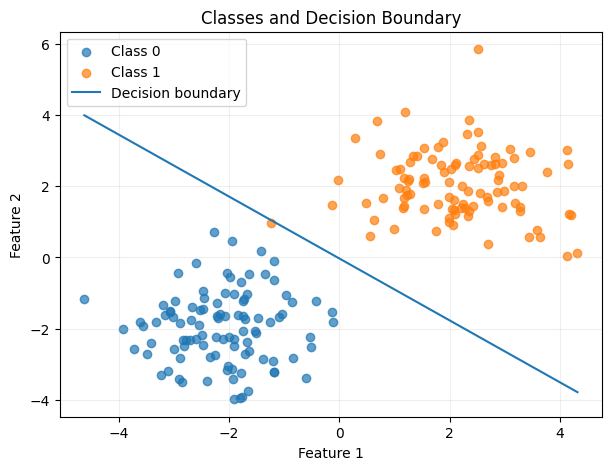

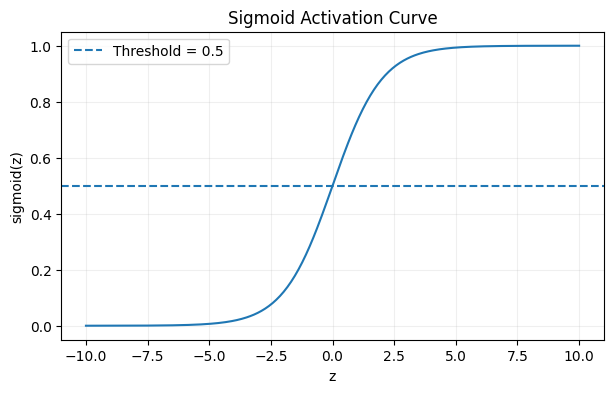

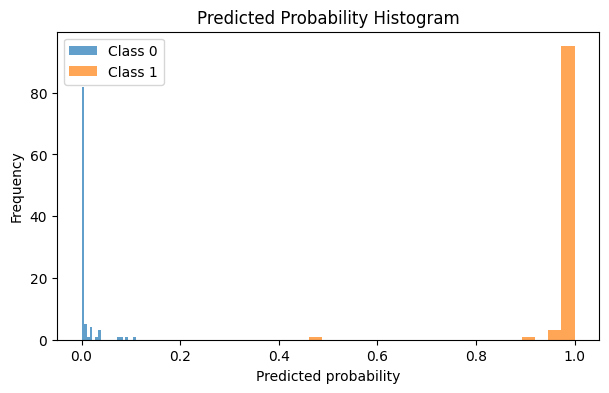

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(class0[:,0], class0[:,1], label="Class 0", alpha=0.7)
plt.scatter(class1[:,0], class1[:,1], label="Class 1", alpha=0.7)

xx = np.linspace(X_binary[:,0].min(), X_binary[:,0].max(), 200)
yy = -(weights[0] * xx + bias) / weights[1]

plt.plot(xx, yy, label="Decision boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classes and Decision Boundary")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

z = np.linspace(-10, 10, 400)

plt.figure(figsize=(7,4))
plt.plot(z, sigmoid_stable(z))

plt.axhline(0.5, linestyle="--", label="Threshold = 0.5")

plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Activation Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(7,4))

plt.hist(probabilities[y_binary==0], bins=20, alpha=0.7, label="Class 0")
plt.hist(probabilities[y_binary==1], bins=20, alpha=0.7, label="Class 1")

plt.xlabel("Predicted probability")
plt.ylabel("Frequency")
plt.title("Predicted Probability Histogram")
plt.legend()
plt.show()

## Question 4.5 — Demonstrate through code and plots why a single neuron cannot correctly classify XOR. (1 mark)

Probabilities: [0.5 0.5 0.5 0.5]
Predictions: [1 1 1 1]
True labels: [0 1 1 0]
Accuracy: 0.5


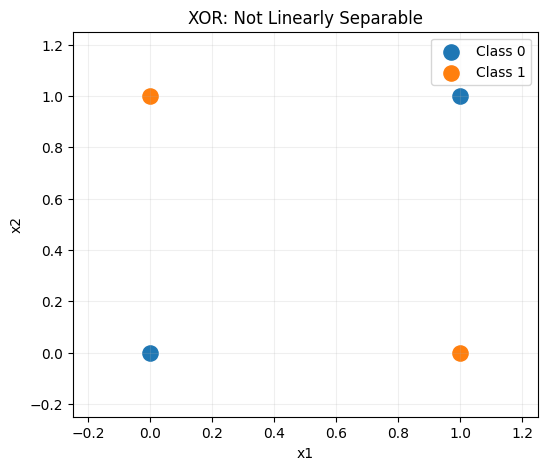

A single neuron can create only one linear boundary, but XOR cannot be separated by one straight line.


In [23]:
X_xor = np.array([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

y_xor = np.array([0., 1., 1., 0.])

wx = np.zeros(2)
bx = 0.0

for _ in range(5000):
    p = sigmoid_stable(X_xor @ wx + bx)
    e = p - y_xor

    wx -= 0.5 * (X_xor.T @ e) / len(y_xor)
    bx -= 0.5 * np.mean(e)

p = sigmoid_stable(X_xor @ wx + bx)
pred = (p >= 0.5).astype(int)

print("Probabilities:", np.round(p, 4))
print("Predictions:", pred)
print("True labels:", y_xor.astype(int))
print("Accuracy:", np.mean(pred == y_xor))

plt.figure(figsize=(6,5))

for label in [0, 1]:
    pts = X_xor[y_xor == label]
    plt.scatter(pts[:,0], pts[:,1], s=120, label=f"Class {label}")

plt.xlim(-0.25, 1.25)
plt.ylim(-0.25, 1.25)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR: Not Linearly Separable")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("A single neuron can create only one linear boundary, but XOR cannot be separated by one straight line.")

# Task 5: Programmatic Expression of Deep Learning Mathematics and Gradient Calculation — 10 Marks

## Question 5.1 — Express the model and MSE programmatically using NumPy. Calculate initial predictions and loss. (2 marks)

In [24]:
x_data = np.array([1.0, 2.0, 3.0, 4.0])
y_data = np.array([3.0, 5.0, 7.0, 9.0])

w = 0.5
b = 0.0
learning_rate = 0.05

def predict(x, w, b):
    return w * x + b

def mse(y_hat, y):
    return np.mean((y_hat - y) ** 2)

y_hat = predict(x_data, w, b)

initial_loss = mse(y_hat, y_data)

print("Initial predictions:", y_hat)
print("Initial loss:", initial_loss)

Initial predictions: [0.5 1.  1.5 2. ]
Initial loss: 25.375


## Question 5.2 — Implement the analytical gradients. (2 marks)

In [25]:
n = len(x_data)

errors = y_hat - y_data

dw_a = (2/n) * np.sum(errors * x_data)
db_a = (2/n) * np.sum(errors)

print("Analytical dL/dw:", dw_a)
print("Analytical dL/db:", db_a)

Analytical dL/dw: -27.5
Analytical dL/db: -9.5


## Question 5.3 — Approximate both gradients using finite differences with ε = 10⁻⁵. (2 marks)

In [26]:
epsilon = 1e-5

def loss_params(wv, bv):
    return mse(predict(x_data, wv, bv), y_data)

dw_n = (
    loss_params(w + epsilon, b) -
    loss_params(w - epsilon, b)
) / (2 * epsilon)

db_n = (
    loss_params(w, b + epsilon) -
    loss_params(w, b - epsilon)
) / (2 * epsilon)

print("Numerical dL/dw:", dw_n)
print("Numerical dL/db:", db_n)

Numerical dL/dw: -27.50000000020236
Numerical dL/db: -9.499999999817987


## Question 5.4 — Implement the same model using PyTorch and calculate gradients using automatic differentiation. (2 marks)

In [27]:
import torch

xt = torch.tensor([1.0, 2.0, 3.0, 4.0])
yt = torch.tensor([3.0, 5.0, 7.0, 9.0])

wt = torch.tensor(0.5, requires_grad=True)
bt = torch.tensor(0.0, requires_grad=True)

yht = wt * xt + bt

loss_t = torch.mean((yht - yt) ** 2)

loss_t.backward()

dw_t = wt.grad.item()
db_t = bt.grad.item()

print("PyTorch loss:", loss_t.item())
print("PyTorch dL/dw:", dw_t)
print("PyTorch dL/db:", db_t)

PyTorch loss: 25.375
PyTorch dL/dw: -27.5
PyTorch dL/db: -9.5


## Question 5.5 — Compare analytical, numerical and PyTorch gradients. Perform one gradient-descent update and verify that loss decreases. (2 marks)

In [28]:
print(f"{'Method':<12} {'dL/dw':>15} {'dL/db':>15}")
print(f"{'Analytical':<12} {dw_a:>15.8f} {db_a:>15.8f}")
print(f"{'Numerical':<12} {dw_n:>15.8f} {db_n:>15.8f}")
print(f"{'PyTorch':<12} {dw_t:>15.8f} {db_t:>15.8f}")

print("\nAnalytical ≈ Numerical:",
      np.allclose([dw_a, db_a], [dw_n, db_n]))

print("Analytical ≈ PyTorch:",
      np.allclose([dw_a, db_a], [dw_t, db_t]))

w_new = w - learning_rate * dw_a
b_new = b - learning_rate * db_a

new_loss = loss_params(w_new, b_new)

print("\nInitial loss:", initial_loss)
print("Updated w:", w_new)
print("Updated b:", b_new)
print("New loss:", new_loss)
print("Loss decreased:", new_loss < initial_loss)

Method                 dL/dw           dL/db
Analytical      -27.50000000     -9.50000000
Numerical       -27.50000000     -9.50000000
PyTorch         -27.50000000     -9.50000000

Analytical ≈ Numerical: True
Analytical ≈ PyTorch: True

Initial loss: 25.375
Updated w: 1.875
Updated b: 0.47500000000000003
New loss: 0.7209375000000005
Loss decreased: True
